# 04 · Exploratory Data Analysis
Univariate, bivariate, and multivariate EDA on the engineered application-level dataset.
This notebook mirrors the analysis shown on the Streamlit pages, in static/offline form.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from utils.feature_engineering import engineer_application_features

app_train = pd.read_csv('../data/application_train.csv')
df = engineer_application_features(app_train)
df.shape


(307511, 133)

## Univariate Analysis

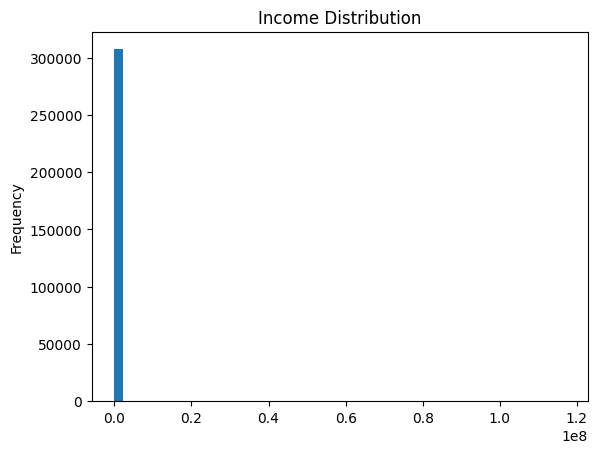

In [2]:
df['AMT_INCOME_TOTAL'].plot(kind='hist', bins=50, title='Income Distribution')
plt.show()


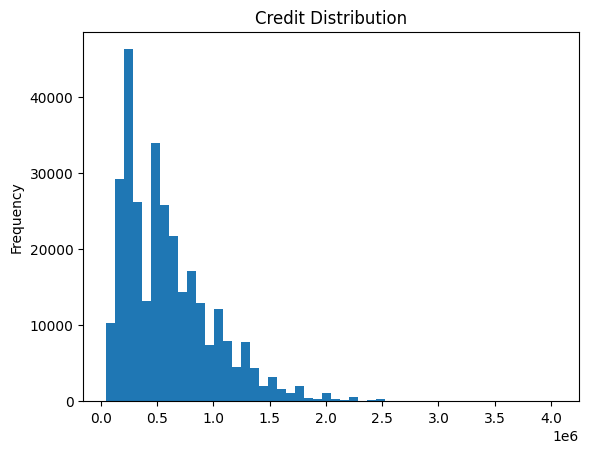

In [3]:
df['AMT_CREDIT'].plot(kind='hist', bins=50, title='Credit Distribution')
plt.show()


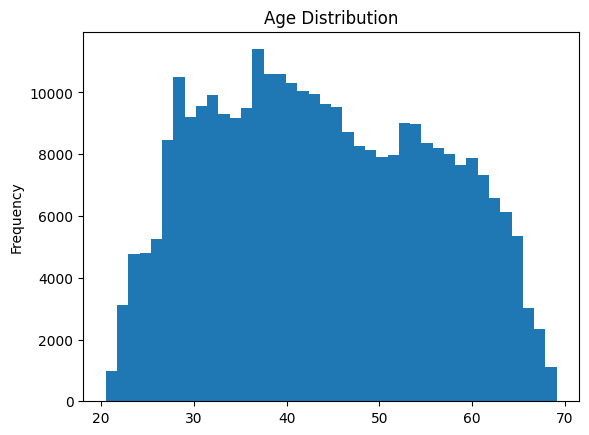

In [4]:
df['AGE_YEARS'].plot(kind='hist', bins=40, title='Age Distribution')
plt.show()


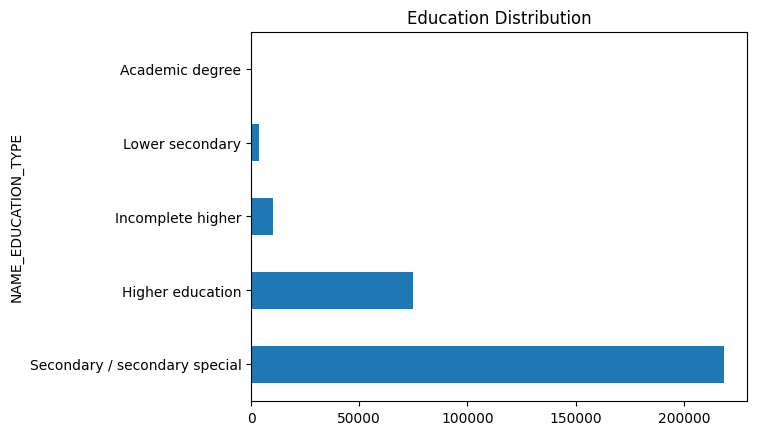

In [5]:
df['NAME_EDUCATION_TYPE'].value_counts().plot(kind='barh', title='Education Distribution')
plt.show()


## Bivariate Analysis

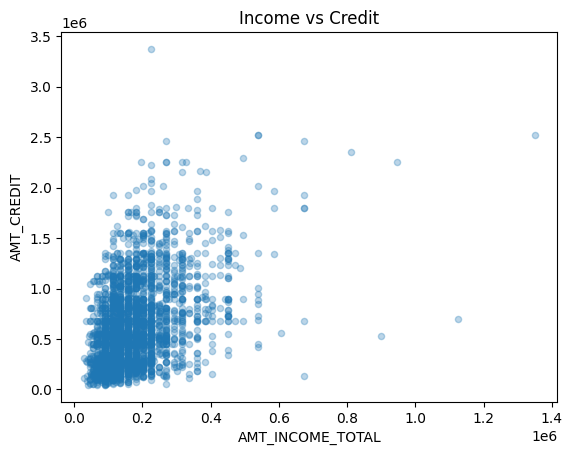

In [6]:
df.sample(3000, random_state=1).plot(kind='scatter', x='AMT_INCOME_TOTAL', y='AMT_CREDIT',
                                            alpha=0.3, title='Income vs Credit')
plt.show()


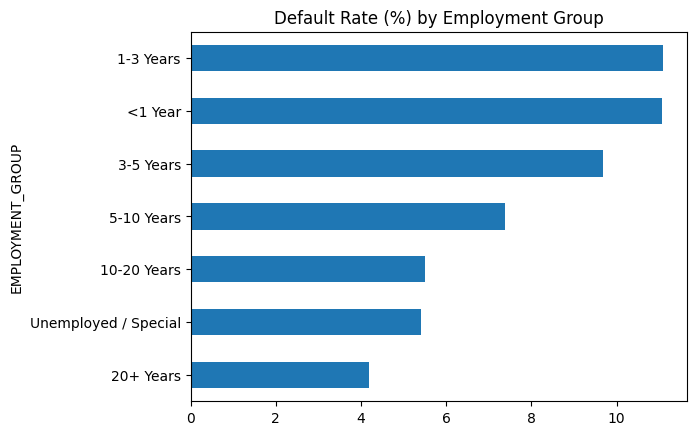

In [7]:
(df.groupby('EMPLOYMENT_GROUP')['TARGET'].mean() * 100).sort_values().plot(
    kind='barh', title='Default Rate (%) by Employment Group')
plt.show()


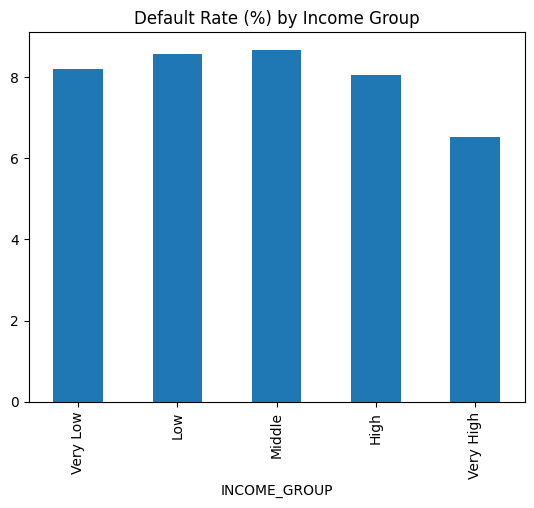

In [8]:
(df.groupby('INCOME_GROUP', observed=True)['TARGET'].mean() * 100).plot(
    kind='bar', title='Default Rate (%) by Income Group')
plt.show()


## Multivariate Analysis

In [9]:
pivot = df.pivot_table(index='AGE_GROUP', columns='INCOME_GROUP', values='TARGET',
                        aggfunc='mean', observed=True) * 100
pivot


INCOME_GROUP,Very Low,Low,Middle,High,Very High
AGE_GROUP,,,,,
20-30,12.728675,12.360321,11.921801,10.591156,7.828235
31-40,10.823105,10.086918,10.708791,9.197240,7.445487
41-50,8.204931,8.088783,8.083275,7.593270,6.256576
51-60,5.788796,6.309013,5.963006,6.578213,5.552239
60+,4.960366,4.962330,5.375754,4.922322,4.286649


In [10]:
import numpy as np
num_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS',
            'EMPLOYMENT_YEARS', 'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME']
corr = df[num_cols].corr(numeric_only=True)
corr


,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_TO_INCOME,ANNUITY_TO_INCOME
TARGET,1.000000,-0.003982,-0.030369,-0.012817,-0.078234,-0.074971,-0.007727,0.014265
AMT_INCOME_TOTAL,-0.003982,1.000000,0.156870,0.191657,-0.027267,0.013003,-0.108191,-0.153033
AMT_CREDIT,-0.030369,0.156870,1.000000,0.770138,0.055427,0.091296,0.651097,0.373921
AMT_ANNUITY,-0.012817,0.191657,0.770138,1.000000,-0.009452,0.053611,0.393239,0.484624
AGE_YEARS,-0.078234,-0.027267,0.055427,-0.009452,1.000000,0.352305,0.121969,0.081490
EMPLOYMENT_YEARS,-0.074971,0.013003,0.091296,0.053611,0.352305,1.000000,0.071603,0.024462
CREDIT_TO_INCOME,-0.007727,-0.108191,0.651097,0.393239,0.121969,0.071603,1.000000,0.788113
ANNUITY_TO_INCOME,0.014265,-0.153033,0.373921,0.484624,0.081490,0.024462,0.788113,1.000000


## Summary of Observations

- Default rate varies meaningfully by employment group, income group, and age group — see bar charts above.
- Correlation values show the *strength of linear association only*; they are not evidence of causation and are
  reported as "observed relationships" throughout this project, consistent with the assignment's Important Rule.
- All findings here feed directly into the Streamlit dashboard's pages 05–20 and the final business
  recommendations on page 20.
